## CN Class and Cocktail mixer

In [1]:

import numpy as np
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import h5py
import os

class ChemicalNetwork:

    def __init__(self, num_species, num_input, num_output, n_desc, conc_hidden, conc_out):
        """
        Initialize the Chemical Network

        :param num_species: Number of chemical species in the network
        :n_desc: Number of descendants of K
        :conc_hidden/out: concentration of the species in the hidden/out layers
        """

        self.num_species = num_species
        self.num_input = num_input      # number of input nodes
        self.num_output = num_output    # number of output nodes 

        if (num_input + num_output > num_species):  
             raise ValueError("Input and output layers overlap")

        self.num_desc = n_desc

        self.concentration = np.ones(num_species) # total concentrations
        self.concentration[:num_species-num_output] = conc_hidden # the input concentrations are overwritten when running inference dynamics 
        self.concentration[num_species-num_output:] = conc_out
        self.conc_out = conc_out
        self.conc_hidden = conc_hidden
        self.conc_hidden_min = 0.2
        self.conc_hidden_max = 5
        self.list_conc_out = conc_out*np.ones(n_desc)
        self.list_conc_hidden = conc_hidden*np.ones(n_desc)

        # initialisation of the dynamic variables (affinities)
        self.states = [np.zeros(num_species) for _ in range(n_desc)] # neuronal variables for all descendants

        # interaction matrix 
        self.Ks = [np.zeros((num_species, num_species)) for _ in range(n_desc)]
        self.Ksymm = np.ones((num_species, num_species)) # used to enforce symmetry of Ks 
        for i in range(1,num_species):
            for j in range(0,i):
                self.Ksymm[i,j]=0.0

        # print('Ksymm=',self.Ksymm)
        self.Kmask = np.ones((num_species, num_species))
        for i in range(0,num_species): # used to set self-interactions = 0
            self.Kmask[i,i] = 0.0
        self.Kmask[:num_input,:num_input] = 0.0 # used to switch off the interaction between input species 
        # print('Kmask=',self.Kmask)

        # score ranks the different models 
        self.scores = np.zeros(n_desc) 

    def clone_K(self,mean,sigma): # this routine should be vectorized 
        K=self.Ks[0]
        for i in range(1,self.num_desc):
            normal_matrix = np.random.lognormal(mean=mean, sigma=sigma, size=(self.num_species,self.num_species))
            normal_matrix = normal_matrix*self.Kmask*self.Ksymm
            normal_matrix = normal_matrix+normal_matrix.T
            self.Ks[i] = np.minimum(K*normal_matrix,np.power(10.,4.))  

    def initialise_K(self,mean_0,sigma_0,mean,sigma):
        K= np.random.lognormal(mean=mean_0, sigma=sigma_0, size=(self.num_species,self.num_species))
        K=K*self.Kmask*self.Ksymm
        K=K+K.T
        self.Ks[0]=K
        self.clone_K(mean, sigma)

# vectorized
    def network_dynamics(self, K, Input_concentrations, conc_hidden, conc_out, precision):
        """
        Vectorized network dynamics where all patterns share the same interaction matrix (K).

        :param K: Interaction matrix (shape: [num_species, num_species])
        :param Input_concentrations: Batch of input concentration vectors (shape: [batch_size, num_input])
        :param conc_hidden: Hidden layer concentration
        :param conc_out: Output layer concentration
        :param precision: Tolerance for convergence
        :return: Final states for all input patterns, and the number of iterations per pattern
        """
        batch_size = Input_concentrations.shape[0]  # Number of input patterns
        num_species = self.num_species

        # Initialize concentrations for all input patterns
        concentrations = np.ones((batch_size, num_species)) * conc_hidden
        concentrations[:, :self.num_input] = Input_concentrations  # Set input concentrations
        concentrations[:, -self.num_output:] = conc_out  # Set output concentrations

        # Initialize states and convergence variables
        states = np.zeros((batch_size, num_species))  # Shape: [batch_size, num_species]
        prev_states = np.zeros_like(states)
        ac_precision = 2.0 * precision * np.ones(batch_size)  # One precision value per pattern
        # max_iterations = 1000  # Optional: Set a maximum number of iterations
        iteration_counts = np.zeros(batch_size, dtype=int)  # Track iterations for each pattern

        # Iteratively solve for equilibrium concentrations
        while np.any(ac_precision > precision):  # Continue until all patterns converge
            prev_states = states.copy()
            states = concentrations / (1.0 + np.dot(states, K.T))  # Update states in parallel for all patterns
            deltas = 2.0 * np.abs(prev_states - states) / (np.abs(prev_states + states) + precision / 10)
            ac_precision = np.max(deltas, axis=1)  # Update precision for each pattern
            iteration_counts += 1
#        if np.all(iteration_counts >= max_iterations):  # Safety check to prevent infinite loops
#            break

        return states, iteration_counts


    def compute_losses(self,labels,outputs,loss,out_losses):
        N_patt = labels.shape[0]
        c_inf = np.min(labels)
        c_sup = np.max(labels)

        if loss == 1:  # entropic loss

            s_matrix = (labels - c_inf) / (c_sup - c_inf) 
            outputs_clipped = np.clip(outputs, 1e-10, self.conc_out)
            off_list=np.log(np.max((1-s_matrix)*outputs_clipped,axis=1))
            on_list=np.min(s_matrix*np.log(outputs_clipped),axis=1)
            list_losses=off_list-on_list
            score = np.average(list_losses)

            ## two old versions 
            #indinc = (labels - c_inf) / (c_sup - c_inf)  # Shape: [N_patt, num_output]
            #outputs_clipped = np.clip(outputs, 1e-10, self.conc_out)  # to avoid computing 1./0. and log(0.)  
            #num = np.sum(indic * outputs, axis=1)            
            #den = np.max((1-indic) * outputs, axis=1)
            ##if out_losses == 1:
            #list_losses = -np.log(num/den)    
            #score = np.sum(-np.log(num/den))
            ##
            ## version with preaverage over the patterns belonging to the same class  
            ##
            #label_indices = np.argmax(labels, axis=1) # Shape: [N_patt]; label_indices=0,1,2
            #num_labels=labels.shape[1]
            #score_label=np.zeros(num_labels)
            #for label in range(num_labels):
            #    mask = (label_indices == label)  # Boolean mask for current label    
            #    score_label[label]=np.sum(list_losses[mask])
            #score=np.max(score_label)

        elif loss == 2:  # mean squared error (mse) 

            if out_losses == 1:
                list_losses = np.sum(np.power(outputs - labels, 2),axis=1)
            score = np.average(np.power(outputs - labels, 2))*3./2

        elif loss == 3: # contrast loss

            s_matrix = (labels - c_inf) / (c_sup - c_inf)  # Shape: [N_patt, num_output]
            outputs_clipped = np.clip(outputs, 1e-10, self.conc_out)/self.conc_out  # regularizators  

            #label_indices = np.argmax(labels, axis=1) # Shape: [N_patt]; label_indices=0,1,2
            #num_labels=labels.shape[1]
            on_matrix=s_matrix*np.log(outputs_clipped)            
            off_matrix=(1.-s_matrix)*outputs_clipped

            ## first version of the score 
            # score=-np.average(on_matrix)+0.5*np.average(np.log(np.average(off_matrix,axis=0)))
            list_scores=np.log(3./2.*np.average(off_matrix,axis=0))-3.*np.average(on_matrix,axis=0)
            score=np.max(list_scores)
            
            if out_losses == 1:
                list_losses=np.average(on_matrix,axis=1)

        elif loss == 4: # symmetric loss
            
            s_matrix = (labels - c_inf) / (c_sup - c_inf)  # Shape: [N_patt, num_output]
            outputs_clipped = np.clip(outputs, 1e-10, self.conc_out)/self.conc_out  # regularizators 

            on_matrix=np.log(1-np.min(s_matrix*outputs_clipped,axis=1))
            off_matrix=np.log(np.max((1-s_matrix)*outputs_clipped,axis=1))

            list_losses=on_matrix+off_matrix
            score=np.average(list_losses)


        else:
            raise ValueError("Invalid loss type. Must be 1, or 2, or 3, or 4.")

        if out_losses == 1:

            return score , list_losses
        else:
            return score 

# vectorized 
    def test_models(self, patterns, labels, K, conc_hidden, conc_out, precision, loss, out_losses):
        """
        Test models: We assume a one-hot encoding of the labels which are assumed to be equal to (c_inf, c_inf, ..., c_sup, c_inf, ...)

        :param loss: 
            0 - Cross entropy loss
            1 - Unconventional loss (requires c_inf=0 and c_sup=c_out)
            2 - Mean squared (MS) loss
        :return: Average loss across all patterns
        """
#        N_patt = patterns.shape[0]  # Number of patterns
        i_out = self.num_species - labels.shape[1]  # Output indices
#        c_inf = np.min(labels)
#        c_sup = np.max(labels)

        # Run vectorized network dynamics for all patterns
        states, _ = self.network_dynamics(K, patterns, conc_hidden, conc_out, precision)

        # Extract output states for all patterns
        outputs = states[:, i_out:]  # Shape: [N_patt, num_output]
        
        if out_losses == 1:
            score , list_losses = self.compute_losses(labels,outputs,loss,out_losses)
            return score , list_losses
        else:
            score = self.compute_losses(labels,outputs,loss,out_losses)
            return score 


    def parallel_test_models(self, patterns, labels, conc_hidden, conc_out, precision, loss, out_losses):  # Now fully sequential

        n_des = len(self.Ks)
        n_batch=patterns.shape[0]
        self.scores = []  # Clear the previous scores

        if out_losses == 1:
            tab_losses = np.empty((0,n_batch))

        for i in range(n_des):  # Sequential iteration over all Ks while probing different concentrations
            score_list=np.zeros(3)
            concs_hidden=conc_hidden*np.array([0.97,1.0,1.0/0.97])
            concs_hidden=np.minimum(concs_hidden,self.conc_hidden_max)
            concs_hidden=np.maximum(concs_hidden,self.conc_hidden_min)
            if out_losses == 1:
                score_list[0], losses_0 = self.test_models(patterns, labels, self.Ks[i], concs_hidden[0], conc_out, precision,loss, out_losses)
                score_list[1], losses_1 = self.test_models(patterns, labels, self.Ks[i], concs_hidden[1], conc_out, precision,loss, out_losses)
                score_list[2], losses_2 = self.test_models(patterns, labels, self.Ks[i], concs_hidden[2], conc_out, precision,loss, out_losses)
            else:
                score_list[0] = self.test_models(patterns, labels, self.Ks[i], concs_hidden[0], conc_out, precision,loss, out_losses)
                score_list[1] = self.test_models(patterns, labels, self.Ks[i], concs_hidden[1], conc_out, precision,loss, out_losses)
                score_list[2] = self.test_models(patterns, labels, self.Ks[i], concs_hidden[2], conc_out, precision,loss, out_losses)
            iopt=np.argmin(score_list)
            self.list_conc_hidden[i]=concs_hidden[iopt]
            self.scores.append(score_list[iopt])  # Store the resulting score
            if out_losses == 1:
                if iopt == 0:
                    losses=losses_0
                elif iopt == 1:
                    losses=losses_1
                elif iopt == 2:
                    losses=losses_2
                tab_losses = np.vstack(([tab_losses,losses]))        
        if out_losses == 1:
            return tab_losses


    def update_K(self,mean,sigma):
        iopt=np.argmin(self.scores) # carefull, this argmax will pick up the first index when the scores are comparable
        self.scores[0]=self.scores[iopt]
        self.conc_hidden=self.list_conc_hidden[iopt]
        self.Ks[0]=np.copy(self.Ks[iopt])
        self.clone_K(mean,sigma)
        self.list_conc_hidden=self.conc_hidden*np.ones(self.num_desc)


    # used to print out average and variance versus time of the output activities 
    # vectorized
    def output_activities(self, patterns, labels, conc_hidden, conc_out, precision, loss):
        """
        Compute affinities of the most performant model, assuming a one-hot encoding of labels.

        :param patterns: Array of input patterns (shape: [N_patt, num_input])
        :param labels: Array of one-hot encoded labels (shape: [N_patt, num_output])
        :param conc_hidden: Hidden layer concentration
        :param conc_out: Output layer concentration
        :param precision: Precision for equilibrium calculation
        :return: Normalized activities (shape: [num_labels, num_output])
        """
        N_patt = patterns.shape[0]  # Number of patterns
        i_out = self.num_species - labels.shape[1]  # Output indices
        num_output = self.num_species - i_out       # Number of output species
        num_labels = labels.shape[1]               # Number of unique labels

        # Initialize mean activities, variance of the activities, and counts
        activities = np.zeros((num_labels, num_output))
        variance_activity = np.zeros((num_labels, num_output))
        #counts = np.zeros((num_labels, num_output))

        # Run network dynamics for all patterns in a batch
        states, _ = self.network_dynamics(self.Ks[0], patterns, conc_hidden, conc_out, precision)

        # Extract output states for all patterns
        outputs = states[:, i_out:]  # Shape: [N_patt, num_output]

        # Determine the label indices for each pattern (assuming one-hot encoding)
        label_indices = np.argmax(labels, axis=1)  # Shape: [N_patt]

        # Vectorized aggregation of activities and counts
        for label in range(num_labels):
            mask = (label_indices == label)  # Boolean mask for current label
            activities[label] = np.mean(outputs[mask], axis=0) 
            variance_activity[label] = np.var(outputs[mask], axis=0)
        #    counts[label] = np.sum(mask)  # Count occurrences of this label

# no divisions by zero when using balanced batches (i.e., with the same number of patterns/class)             
#        # Normalize activities by counts
#        with np.errstate(divide='ignore', invalid='ignore'):  # Handle division by zero safely
#            # normalized_activities = np.nan_to_num(activities / counts[:, None])
#            normalized_activities = np.nan_to_num(activities / counts)

        out_losses=0
        ac_score = self.compute_losses(labels,outputs,loss,out_losses)
        
        return ac_score, activities, variance_activity

# vectorized
    def test_model(self, patterns, labels, conc_hidden, conc_out, precision):
        """
        Prepares scatter plot data by computing output states and grouping by label.

        :param patterns: Array of input patterns (shape: [N_patt, num_input])
        :param labels: Array of one-hot encoded labels (shape: [N_patt, num_labels])
        :param conc_hidden: Hidden layer concentration
        :param conc_out: Output layer concentration
        :param precision: Precision for equilibrium calculation
        :return: Arrays of affinities grouped by label (one per label)
        """
        # Output layer size and number of labels
        i_out = self.num_species - labels.shape[1]
        num_output = self.num_species - i_out
        num_labels = labels.shape[1]

        # Run network dynamics for all patterns
        states, _ = self.network_dynamics(self.Ks[0], patterns, conc_hidden, conc_out, precision)

        # Extract outputs (equilibrium states of the output species)
        outputs = states[:, i_out:]  # Shape: [N_patt, num_output]

        # Determine label indices for each pattern (assuming one-hot encoding)
        label_indices = np.argmax(labels, axis=1)  # Shape: [N_patt]

        # Initialize affinities for each label as lists
        affinities = [np.empty((0, num_output)) for _ in range(num_labels)]

        # Group outputs by their label using vectorized processing
        for label in range(num_labels):
            mask = (label_indices == label)  # Boolean mask for current label
            affinities[label] = outputs[mask]  # Collect outputs for this label

        return affinities
    def save(self, file_path):
        """
        Save the current ChemicalNetwork object to a file.
        
        :param file_path: Path to the file where the object should be saved.
        """
        with open(file_path, 'wb') as f:
            pickle.dump(self, f)

    @classmethod
    def load(cls, file_path):
        """
        Load a ChemicalNetwork object from a file.
        
        :param file_path: Path to the file from which the object should be loaded.
        :return: A ChemicalNetwork object.
        """
        with open(file_path, 'rb') as f:
            obj = pickle.load(f)
        return obj
    
def gen_patt_label(N_patt, D):
    # Randomly select indices from patterns_0
    # indices = np.random.randint(0, patterns_0.shape[0], size=N_patt)    
    # Balanced number of patterns 
    indices=np.zeros(N_patt,dtype=int)
    N1=int(N_patt/3)
    N2=2*N1
    indices[N1:]+=1
    indices[N2:]+=1
    selected_labels = labels_0[indices, :]
    selected_patterns = patterns_0[indices, :]
    # Apply log-normal scaling to the patterns
    scaling_factors = np.random.lognormal(mean=0, sigma=D, size=(N_patt, selected_patterns.shape[1]))
    scaled_patterns = selected_patterns * scaling_factors
    return scaled_patterns, selected_labels


## Functions for Mutual Information and Plots 

In [3]:
def compute_contrast(x, i):
    # Combine all channels together
    j = int(np.mod(i+1, 3))
    k = int(np.mod(i+2, 3))

    return np.mean(x[i])-max(np.mean(x[j]), np.mean(x[k]))


def compute_mutual_I(x, i, dx=0.01):
    # Combine all channels together
    x_combined = np.concatenate([x[0], x[1], x[2]])
    x_i = x[i]
    
    # Define histogram edges
    edges = np.arange(np.min(x_combined), np.max(x_combined) + dx, dx)
    
    # Compute histograms for the selected index and for the combined data
    counts_i, _ = np.histogram(x_i, bins=edges, density=False)
    counts_combined, _ = np.histogram(x_combined, bins=edges, density=False)
    
    # Total counts for normalization
    total = np.sum(counts_combined)
    if total == 0:
        return 0
    
    # Only consider bins where counts_combined > 0
    valid = counts_combined > 0
    # Compute p_i for valid bins
    p_i = counts_i[valid] / counts_combined[valid]
    # Relative frequency for the combined data in the valid bins
    p = counts_combined[valid] / total
    
    # Only include indices where the ratio is strictly between 0 and 1
    valid_indices = (p_i > 0) & (p_i < 1)
    p_i = p_i[valid_indices]
    p = p[valid_indices]
    
    # Compute the mutual information using the given formula
    numerator = np.sum(p * (p_i * np.log(p_i) + (1 - p_i) * np.log(1 - p_i)))
    normalization = np.log(3) - (2/3) * np.log(2)
  
    
    return 1+numerator/normalization


    



def generate_svg_plots(a_list, colors, lower_bound=-6, ID=""):
    """
    Generates two distinct SVG plots:
      1. A 3D scatter plot (with shadows projected onto the xy-plane).
      2. Histograms of the f_x, f_y, and f_z components (stacked vertically).
    
    In addition, calculates the entropy H_x of the x distribution for each dataset,
    for the combined distribution (all datasets concatenated),
    and for the combination of datasets 1 and 2.
    Then computes a mutual entropy as:
    
         M = H_x(combined) - (1/3*H_x(0) + 2/3*H_x(1,2))
    
    Both SVG outputs preserve editable text.
    
    Parameters:
      a_list       : list of numpy arrays, each with shape (n, 3) containing positive values.
      colors       : list of three color strings, one for each dataset.
      lower_bound  : fixed z-value for the xy-plane shadow and lower limit of the axes.
      scatter_filename : filename for the scatter plot SVG.
      hist_filename    : filename for the histograms SVG.
    """
    scatter_filename = f"SVGs/scatter_{ID}.svg"
    scatter_png = f"ChemClassifierWeb/images/scatter_{ID}.png"
    hist_filename = f"SVGs/histograms_{ID}.svg"
    hist_png = f"ChemClassifierWeb/images/histograms_{ID}.png"
   
    # Scaling factor: convert natural logs to base-10 logs.
    Dec = 1 / np.log(10)
    
    # Compute transformed data for each dataset.
    # Each a is assumed to have three columns: [f_x, f_y, f_z]
    all_x, all_y, all_z = [], [], []
    for a in a_list:
        x = Dec * np.log(a[:, 0])
        y = Dec * np.log(a[:, 1])
        z = Dec * np.log(a[:, 2])
        all_x.append(x)
        all_y.append(y)
        all_z.append(z)
  
    # Compute entropies for the x distributions.
    # H0: for first dataset; H1: for second; H2: for third.
 

    # Define tick positions from 0 to lower_bound in steps of -2.
    ticks = np.arange(0, lower_bound - 0.1, -1)  # subtract small value to ensure inclusion
    # Create tick labels: 0 is displayed as "1", other ticks as 10^{n}.
    labels = ["1" if tick == 0 else r'$10^{' + str(int(tick)) + '}$' for tick in ticks]
    font_size=28
    label_font=15

    # ======================================================
    # 1. Create the 3D Scatter Plot with Shadows and Export SVG
    # ======================================================
    fig_scatter = plt.figure(figsize=(10, 10))
    ax_scatter = fig_scatter.add_subplot(111, projection='3d')
   
    point_size = 10      # marker size for scatter points
    shadow_alpha = 0.05  # transparency for shadow points
    shadow_size = 1      # marker size for shadows
    
    # Plot each dataset in its color.
    for i, color in enumerate(colors):
        x = all_x[i]
        y = all_y[i]
        z = all_z[i]
        ax_scatter.scatter(x, y, z, color=color, s=point_size)
        # Plot shadow by re-plotting with z fixed at lower_bound.
        ax_scatter.scatter(x, y, zs=lower_bound, zdir='z', color=color, alpha=shadow_alpha, s=shadow_size)
    
    # Remove default axis labels; add custom axis names via text.
    ax_scatter.set_xlabel('')
    ax_scatter.set_ylabel('')
    ax_scatter.set_zlabel('')
    ax_scatter.text2D(0.27, 0.87, r'$f_x$', fontsize=font_size, transform=ax_scatter.transAxes)
    ax_scatter.text2D(0.73, 0.87, r'$f_y$', fontsize=font_size, transform=ax_scatter.transAxes)
    ax_scatter.text2D(1.0, 0.5, r'$f_z$', fontsize=font_size, transform=ax_scatter.transAxes)
    
    # Set limits for each axis.
    ax_scatter.set_xlim(lower_bound, 0)
    ax_scatter.set_ylim(lower_bound, 0)
    ax_scatter.set_zlim(lower_bound, 0)
    
    # Apply same ticks/labels on all three axes.
    ax_scatter.set_xticks(ticks)
    ax_scatter.set_xticklabels(labels, fontsize=label_font)
    ax_scatter.set_yticks(ticks)
    ax_scatter.set_yticklabels(labels,fontsize=label_font)
    ax_scatter.set_zticks(ticks)
    ax_scatter.set_zticklabels(labels,fontsize=label_font)
    
    ax_scatter.view_init(elev=20, azim=45)
    #ax_scatter.set_title("3D Scatter Plot with Shadows", fontsize=16)
    #fig_scatter.tight_layout()
    # Export scatter plot to SVG.
    print(scatter_filename)
    fig_scatter.savefig(scatter_filename, facecolor='none', transparent=True, format="svg")
    fig_scatter.savefig(scatter_png, facecolor='none', transparent=True, format="png")
    plt.close(fig_scatter)
    
    # ======================================================
    # 2. Create the Histograms Plot and Export SVG
    # ======================================================
    # Create a figure with three vertically stacked subplots.
    fig_hist = plt.figure(figsize=(8, 16))
    ax_hist_x = fig_hist.add_subplot(311)
    ax_hist_y = fig_hist.add_subplot(312)
    ax_hist_z = fig_hist.add_subplot(313)

    bins = 30  # number of bins for the histograms.
    
    # Plot histogram for f_x.
    for i, color in enumerate(colors):
        ax_hist_x.hist(all_x[i], bins=bins, color=color,density=True, alpha=0.7)
    # Plot histogram for f_y.
    for i, color in enumerate(colors):
        ax_hist_y.hist(all_y[i], bins=bins, color=color,density=True, alpha=0.7)
 
    for i, color in enumerate(colors):
        ax_hist_z.hist(all_z[i], bins=bins, color=color,density=True, alpha=0.7)
    
 
    for ax_hist in [ax_hist_x, ax_hist_y, ax_hist_z]:
        ax_hist.set_xlim(lower_bound, 0)
        ax_hist.set_xticks(ticks)
        ax_hist.set_xticklabels(labels, fontsize=label_font)
  
    
    ax_hist_x.text(0.05, 0.9, r'$f_x$', fontsize=font_size, transform=ax_hist_x.transAxes)
    ax_hist_y.text(0.05, 0.9, r'$f_y$', fontsize=font_size, transform=ax_hist_y.transAxes)
    ax_hist_z.text(0.05, 0.9, r'$f_z$', fontsize=font_size, transform=ax_hist_z.transAxes)

    mutual_information_x= compute_mutual_I(all_x,0)
    mutual_information_y= compute_mutual_I(all_y,1)
    mutual_information_z= compute_mutual_I(all_z,2)


    ax_hist_x.text(0.6, 0.9, f'$I_X = {mutual_information_x:.2f}$', fontsize=font_size, color='red', transform=ax_hist_x.transAxes)
    ax_hist_y.text(0.6, 0.9, f'$I_Y = {mutual_information_y:.2f}$', fontsize=font_size, color='blue', transform=ax_hist_y.transAxes)
    ax_hist_z.text(0.6, 0.9, f'$I_Z = {mutual_information_z:.2f}$', fontsize=font_size, color='green', transform=ax_hist_z.transAxes)

    
    fig_hist.tight_layout()
  
    fig_hist.savefig(hist_filename, format="svg")
    fig_hist.savefig(hist_png, format="png")
    plt.close(fig_hist)
    return mutual_information_x, mutual_information_y, mutual_information_z
    # Optionally, display the SVG files in a Jupyter Notebook.
    # disp.display(disp.SVG(filename=scatter_filename))
    # disp.display(disp.SVG(filename=hist_filename))
    







## Initialize parameters

In [5]:

# Make sure ChemicalNetwork, gen_patt_label, generate_svg_plots are imported or defined appropriately

N_species = 15
N_inp = 6
N_out = 3

N_desc = 50 + 1
Conc_hidden = 1.
Conc_out = 1.
mean = -0.0  # mean of the normal distribution used when cloning (0.02)
sigma = 0.5  # variance used when cloning
sigma_0 = np.sqrt(2.)  # variance of the starting patterns' distribution 
mean_0 = -1.

pp = 0.0  # pp=0 for digital labels
labels_0 = np.array([
    [Conc_out * (10 - pp) / 10., Conc_out * pp / 10., Conc_out * pp / 10.],
    [Conc_out * pp / 10., Conc_out * (10 - pp) / 10., Conc_out * pp / 10.],
    [Conc_out * pp / 10., Conc_out * pp / 10., Conc_out * (10 - pp) / 10.]
])

precision = np.power(10., -6)

noise_scan    = range(10, 121, 5)
drift_scan    = [0, 2, 4, 8]
cocktail_scan = range(1, 49)

## Generate scatterplots and histograms

In [4]:



# Dictionaries for aggregated data.
# Each key is a tuple (drift, noise), and each value is a list of lists
# where each sublist contains [I_x, I_y, I_z] or [D_x, D_y, D_z] for one cocktail set.
aggregated_I_values = {}
aggregated_D_values = {}

# Loop over drift and noise first so that results are grouped by these two parameters.
for drift in drift_scan:
    for noise in noise_scan:
        # Initialize lists for the (drift, noise) combination
        key = (drift, noise)
        aggregated_I_values[key] = []
        aggregated_D_values[key] = []
        
        # Now loop over all cocktail sets and accumulate the values.
        for cocktail_set in cocktail_scan:
            pattern_filename = f"PKLs/patterns_F{cocktail_set}.pkl"
            with open(pattern_filename, 'rb') as f:
                patterns_0 = pickle.load(f)
            
            NS_ratio = noise * 0.01
            D = sigma_0 * NS_ratio

            # Construct an ID (cocktail set, drift, noise) for the chemical network file
            ID = f"2_F{cocktail_set}_{drift}_{noise}"
            CN_filename = f"PKLs/CN{ID}.pkl"
            CN = ChemicalNetwork.load(CN_filename)
            print(f"Processing {CN_filename}")
            
            # Generate test patterns and labels
            patterns_scatter, labels_scatter = gen_patt_label(4200, D)
            a1, a2, a3 = CN.test_model(patterns_scatter, labels_scatter, CN.conc_hidden, CN.conc_out, precision)
            
            # Process the activations for each of the three outputs (channels)
            all_x, all_y, all_z = [], [], []
            a_list = [a1, a2, a3]
            Dec = 1 / np.log(10)
            for a in a_list:
                x = Dec * np.log(a[:, 0])
                y = Dec * np.log(a[:, 1])
                z = Dec * np.log(a[:, 2])
                all_x.append(x)
                all_y.append(y)
                all_z.append(z)
            
            # Compute mutual information values from the channels
            I_x = compute_mutual_I(all_x, 0)
            I_y = compute_mutual_I(all_y, 1)
            I_z = compute_mutual_I(all_z, 2)
            
            # Compute contrast values from the channels
            D_x = compute_contrast(all_x, 0)
            D_y = compute_contrast(all_y, 1)
            D_z = compute_contrast(all_z, 2)
            
            # Combine the I and contrast values per cocktail set
            combined_I = [I_x, I_y, I_z]
            combined_D = [D_x, D_y, D_z]
            
            # Append the values to the corresponding (drift, noise) key,
            # thereby concatenating results across cocktail sets.
            aggregated_I_values[key].append(combined_I)
            aggregated_D_values[key].append(combined_D)

# After running the loops, aggregated_I_values and aggregated_D_values will contain
# all data for each (drift, noise) pair across all cocktail sets.
# For example, to access the mutual information values for drift=2 and noise=30:
example_key = (2, 30)
print("Mutual Information for drift=2, noise=30:", aggregated_I_values[example_key])
print("Contrast values for drift=2, noise=30:", aggregated_D_values[example_key])


# ------------------------------

#
# ------------------------------

# Save the aggregated data to a file so you can reload it later if needed.
# with open('aggregated_data_MSE.pkl', 'wb') as f:
#     pickle.dump({
#         'I': aggregated_I_values,
#         'D': aggregated_D_values
#     }, f)

# print("Aggregated data saved to 'aggregated_data.pkl'.")

#

# -----------------------------------------

FileNotFoundError: [Errno 2] No such file or directory: 'PKLs/patterns_F1.pkl'

C:\Users\user\AppData\Local\Temp\ipykernel_73468\689276190.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


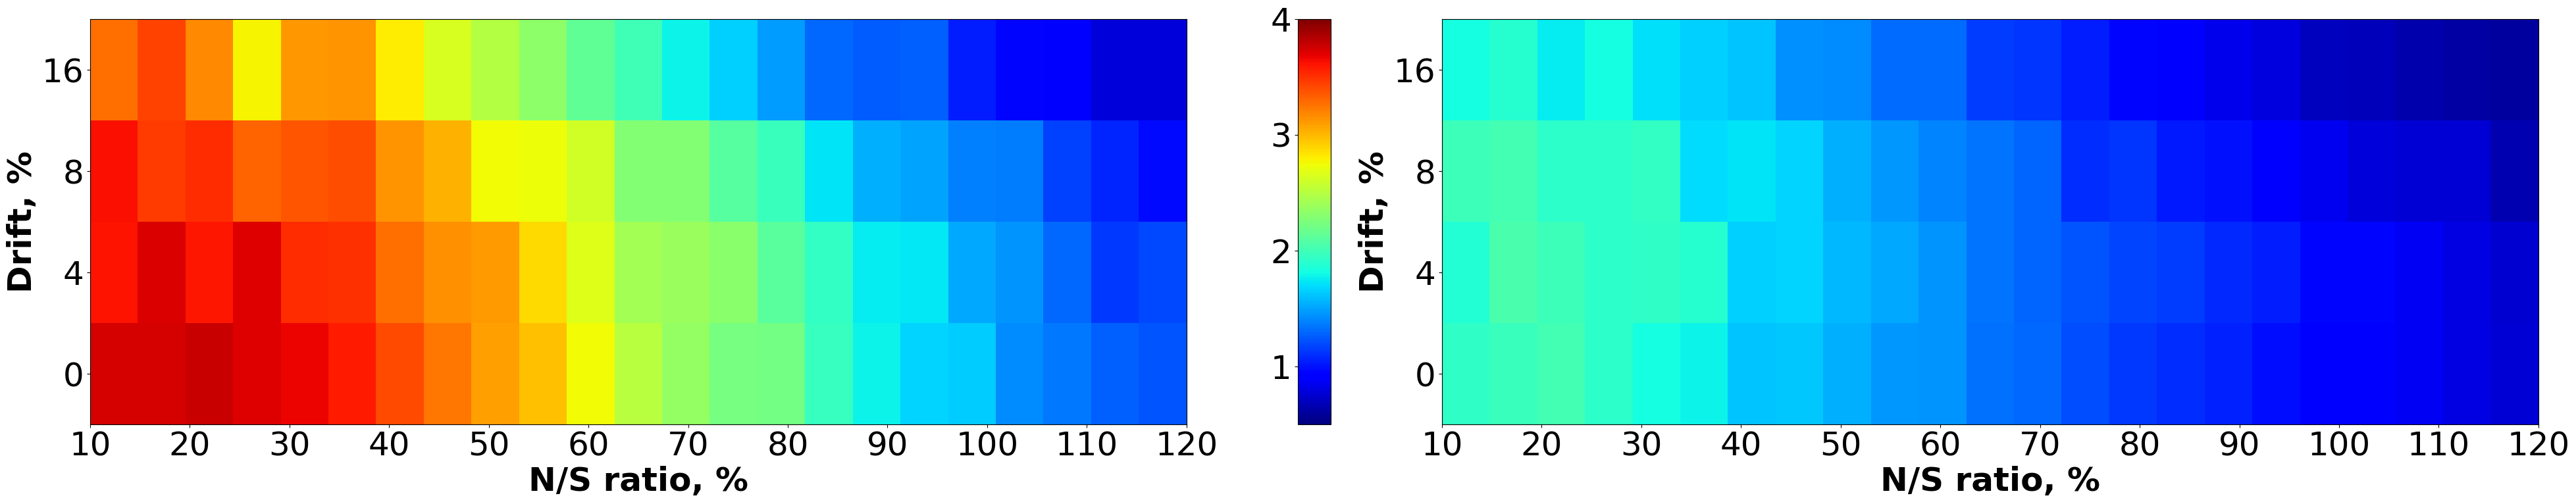

C:\Users\user\AppData\Local\Temp\ipykernel_73468\689276190.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


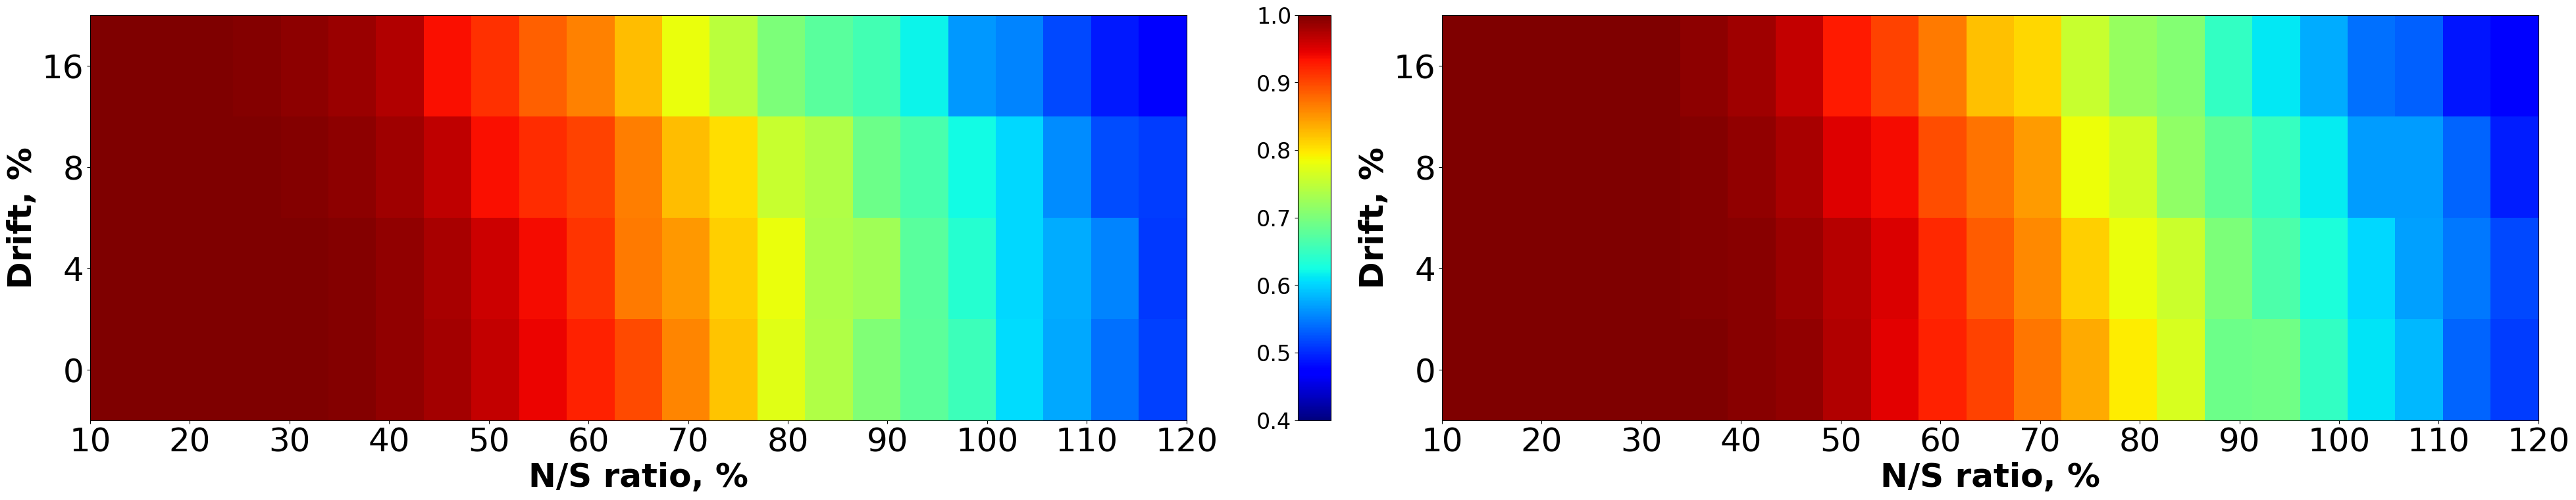

In [6]:
import matplotlib.gridspec as gridspec

with open('aggregated_data.pkl', 'rb') as f:
    data = pickle.load(f)

aggregated_I_values = data['I']
aggregated_D_values = data['D']

# Flatten the nested lists for each key.
# For example, if aggregated_I_values[(0, 10)] is a list of lists, we convert it to a single flat list.
flat_I = {
    key: [value for sublist in val for value in sublist]
    for key, val in aggregated_I_values.items()
}
flat_D = {
    key: [value for sublist in val for value in sublist]
    for key, val in aggregated_D_values.items()
}

with open('aggregated_data_MSE.pkl', 'rb') as f:
    data = pickle.load(f)

aggregated_I_values = data['I']
aggregated_D_values = data['D']

# Flatten the nested lists for each key.
# For example, if aggregated_I_values[(0, 10)] is a list of lists, we convert it to a single flat list.
flat_I_MSE = {
    key: [value for sublist in val for value in sublist]
    for key, val in aggregated_I_values.items()
}
flat_D_MSE = {
    key: [value for sublist in val for value in sublist]
    for key, val in aggregated_D_values.items()
}


# Define the desired keys:
extent_vals = [10, 120, 0, 8]
drift_scan = [0, 2, 4, 8]
noise_scan = list(range(10, 121, 5))  # produces 23 noise values: 10, 15, 20, ... 120

# For demonstration, let’s build grids for median I and median D.
# (In your actual workflow you likely computed these earlier.)
n_drifts = len(drift_scan)
n_noises = len(noise_scan)

# Initialize grids with shape (n_drifts, n_noises)
# If a key is missing, we set its value to np.nan.
median_I_grid = np.empty((n_drifts, n_noises))
median_I_grid.fill(np.nan)
median_D_grid = np.empty((n_drifts, n_noises))
median_D_grid.fill(np.nan)
median_I_MSE_grid=np.empty((n_drifts, n_noises))
median_I_MSE_grid.fill(np.nan)
median_D_MSE_grid=np.empty((n_drifts, n_noises))
median_D_MSE_grid.fill(np.nan)
# Loop over each (drift, noise) key and compute the median from the corresponding list.
for i, drift in enumerate(drift_scan):
    for j, noise in enumerate(noise_scan):
        key = (drift, noise)
        if key in flat_I:
            median_I_grid[i, j] = np.median(flat_I[key])
        if key in flat_D:
            median_D_grid[i, j] = np.median(flat_D[key])
        if key in flat_I_MSE:
            median_I_MSE_grid[i, j] = np.median(flat_I_MSE[key])
        if key in flat_D:
            median_D_MSE_grid[i, j] = np.median(flat_D_MSE[key])
            
# -------------------------------------------------------------------------
# Plot the heatmaps.
# We want an overall figure of 23x8 inches.

font_axes=36
fig = plt.figure(figsize=(48, 8))
# Specify width ratios: left and right heatmaps get equal width; middle column is narrow.
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 0.03, 1], wspace=0.15)

# Create the left and right axes for the heatmaps, and an axis for the colorbar.
ax_left = fig.add_subplot(gs[0])
ax_right = fig.add_subplot(gs[2])
cbar_ax = fig.add_subplot(gs[1])

# ------------------------------
# Plot the left heatmap.
im_left = ax_left.imshow(
    median_D_grid,
    origin='lower',
    extent=extent_vals,
    aspect='auto',
    cmap='jet',
    vmin=0.5,
    vmax=4
)
ax_left.set_xlabel("N/S ratio, %", fontsize=font_axes, fontweight='bold')
ax_left.set_ylabel("Drift, %", fontsize=font_axes,fontweight='bold')
ax_left.set_xticks(list(range(10, 121, 10)))
# Set y-ticks at the centers: 1, 3, 5, 7. Label them as 0,2,4,8.
ax_left.set_yticks([1, 3, 5, 7])
ax_left.set_yticklabels(["0", "4", "8", "16"])
ax_left.tick_params(axis='both', labelsize=font_axes)

# ------------------------------
# Plot the right heatmap.
im_right = ax_right.imshow(
    median_D_MSE_grid,
    origin='lower',
    extent=extent_vals,
    aspect='auto',
    cmap='jet',
    vmin=0.5,
    vmax=4
)
ax_right.set_xlabel("N/S ratio, %", fontsize=font_axes, fontweight='bold')
ax_right.set_ylabel("Drift, %", fontsize=font_axes,fontweight='bold')
ax_right.set_xticks(list(range(10, 121, 10)))
ax_right.set_yticks([1, 3, 5, 7])
ax_right.set_yticklabels(["0", "4", "8", "16"])
ax_right.tick_params(axis='both', labelsize=font_axes)

# ------------------------------
# Create a common colorbar in the middle column. We can use either image as a reference,
# since both share the same color limits.
cbar = fig.colorbar(im_right, cax=cbar_ax)
cbar.ax.tick_params(labelsize=font_axes)
cbar.ax.yaxis.set_ticks_position('left')
#cbar_ax.set_ylabel("Color scale", fontsize=24)

# ------------------------------
# Add a common title for the entire figure.
#fig.suptitle("Median On/Off contrast, in decades", fontsize=32)

# Adjust layout. Increase the right margin if needed so the colorbar fits.
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Plot the heatmaps.
# We want an overall figure of 23x8 inches.
fig = plt.figure(figsize=(48, 8))
# Specify width ratios: left and right heatmaps get equal width; middle column is narrow.
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 0.03, 1], wspace=0.15)

# Create the left and right axes for the heatmaps, and an axis for the colorbar.
ax_left = fig.add_subplot(gs[0])
ax_right = fig.add_subplot(gs[2])
cbar_ax = fig.add_subplot(gs[1])

# ------------------------------
# Plot the left heatmap.
im_left = ax_left.imshow(
    median_I_grid, origin='lower', extent=extent_vals,
                    aspect='auto', cmap='jet',vmin=0.4, vmax=1)
ax_left.set_xlabel("N/S ratio, %", fontsize=font_axes, fontweight='bold')
ax_left.set_ylabel("Drift, %", fontsize=font_axes, fontweight='bold')
ax_left.set_xticks(list(range(10, 121, 10)))
# Set y-ticks at the centers: 1, 3, 5, 7. Label them as 0,2,4,8.
ax_left.set_yticks([1, 3, 5, 7])
ax_left.set_yticklabels(["0", "4", "8", "16"])
ax_left.tick_params(axis='both', labelsize=font_axes)

# ------------------------------
# Plot the right heatmap.
im_right = ax_right.imshow( median_I_MSE_grid, origin='lower', extent=extent_vals,
                    aspect='auto', cmap='jet',vmin=0.4, vmax=1)
ax_right.set_xlabel("N/S ratio, %", fontsize=font_axes, fontweight='bold')
ax_right.set_ylabel("Drift, %", fontsize=font_axes, fontweight='bold')
ax_right.set_xticks(list(range(10, 121, 10)))
ax_right.set_yticks([1, 3, 5, 7])
ax_right.set_yticklabels(["0", "4", "8", "16"])
ax_right.tick_params(axis='both', labelsize=font_axes)

# ------------------------------
# Create a common colorbar in the middle column. We can use either image as a reference,
# since both share the same color limits.
cbar = fig.colorbar(im_right, cax=cbar_ax)
cbar.ax.tick_params(labelsize=24)
cbar.ax.yaxis.set_ticks_position('left')
#cbar_ax.set_ylabel("Color scale", fontsize=24)

# ------------------------------
# Add a common title for the entire figure.
#fig.suptitle("Median On/Off contrast, in decades", fontsize=32)

# Adjust layout. Increase the right margin if needed so the colorbar fits.
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Analyze Sparcity of  Chemical Networks

In [8]:
import numpy as np
import pickle

noise_scan    = range(10, 121, 5)
drift_scan    = [0, 2, 4, 8]
cocktail_scan = range(1, 49)

# Ensure that drift_scan, noise_scan, and cocktail_scan are defined.
# Example:
# drift_scan = [0, 2, 4, 8]
# noise_scan = list(range(10, 121, 5))
# cocktail_scan = range(1, some_number)

# Initialize dictionary for sparsity values.
sparsity_values = {}

N_pairs = 90

for drift in drift_scan:
    for noise in noise_scan:
        key = (drift, noise)
        # Initialize the list for this key only once.
        if key not in sparsity_values:
            sparsity_values[key] = []
            
        for cocktail_set in cocktail_scan:
            ID = f"_F{cocktail_set}_{drift}_{noise}"
            filename = f"PKLs/CN{ID}.pkl"
            
            # Load the chemical network.
            CN = ChemicalNetwork.load(filename)
            
            # Define the cutoff and process the adjacency matrix.
            K_cut_off = 1
            adj_matrix = CN.Ks[0].copy()  # e.g., a 15x15 matrix
            adj_matrix[adj_matrix < K_cut_off] = 1
            
            # Compute the normalization and then scale W.
            norm = 12 / np.log(np.max(adj_matrix) )
            # Calculate W in one line:
            W = norm * np.log(adj_matrix )
            
            # Compute the dispersion coefficient as sparsity.
            #sparsity = np.sqrt(N_pairs * np.mean(W**2)) / np.mean(W)
            sparsity = np.sqrt(np.mean(W**2)-np.mean(W)**2)/np.mean(W)      
            print(sparsity)
            
            # Append the computed sparsity to the list for this (drift, noise) key.
            sparsity_values[key].append(sparsity)

# Save all the computed sparsity values in one go.
with open('sparsity.pkl', 'wb') as f:
    pickle.dump(sparsity_values, f)

print("Sparsity values saved to 'sparsity.pkl'.")

            

2.2676767467643035
1.790137646469836
2.0833596570928687
2.1936839371689447
2.2043427691383637
2.2441477252159965
2.214902264840295
2.3961314010807437
2.359133818564853
2.3242311301949874
2.08155608368121
2.6386058006054687
2.1714820266611947
2.4240300451587866
2.223087343918235
2.420893740401395
2.247538033660297
2.618185852074881
2.0962584039041365
2.3000503087561426
1.668128278829672
2.431177185568686
2.2095040964910155
2.1876462689693095
2.136033213054787
2.320545126170497
2.107046489062456
2.3595111792606276
2.1951410538507865
2.1490469858668426
2.124787249044447
2.2729379961914487
2.3108839401180608
2.1710264746544574
2.173886844271291
2.3953674360972292
2.3673433909494306
2.3449892401414987
2.3032709566322214
2.032861559073603
2.0344683318869383
2.1178514033662594
2.413252785226982
2.468147804926952
2.1195789717392786
2.0722968115000535
1.9937216721368605
1.7766488804898988
2.264879599291399
2.303299743892544
1.9249951664658747
1.9643088947389635
2.078221963263541
2.1019685184687

KeyboardInterrupt: 

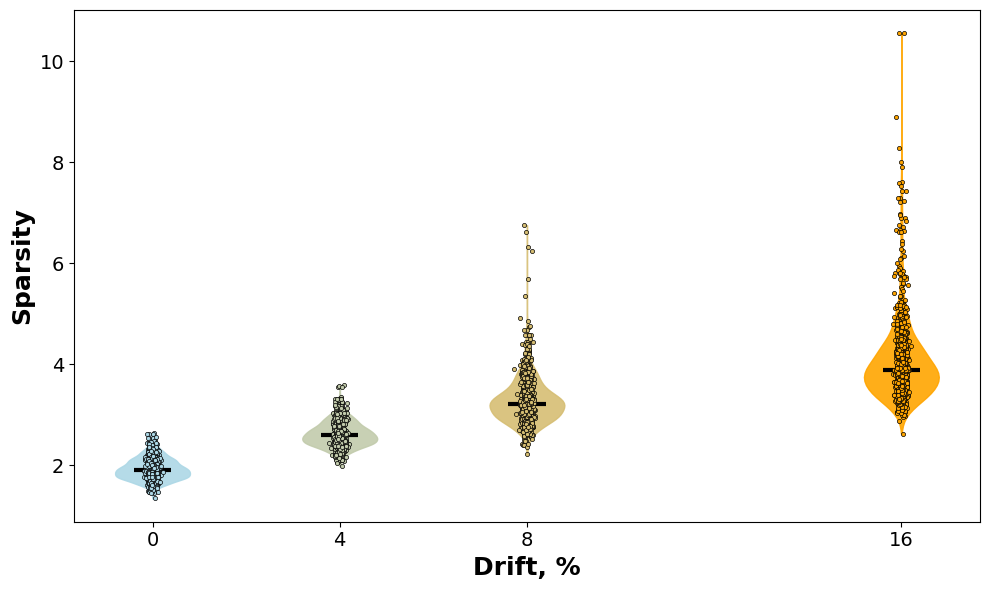

In [9]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load the sparsity data.
with open('sparsity.pkl', 'rb') as f:
    sparsity_values = pickle.load(f)

# Define the original drift values (used for grouping).
drift_scan = [0, 2, 4, 8]

# For each drift value, aggregate all sparsity values across noise levels.
data_by_drift = []
for drift in drift_scan:
    group = []
    for key, sp_list in sparsity_values.items():
        if key[0] == drift:
            group.extend(sp_list)
    data_by_drift.append(group)

# Create a custom colormap that goes from maroon to orange.
# Maroon hex: "#800000" and Orange hex: "#FFA500"
cmap = mcolors.LinearSegmentedColormap.from_list("maroon_orange", ['lightblue', "#FFA500"])

# Create the figure.
plt.figure(figsize=(10, 6))

# Create the violin plots.
vp = plt.violinplot(data_by_drift, positions=drift_scan, widths=0.8,
                    showmedians=True, showextrema=False)

# Customize each violin body and median line based on the drift value.
for i, body in enumerate(vp['bodies']):
    # Normalize drift value between 0 and 1.
    norm_value = (drift_scan[i] - min(drift_scan)) / (max(drift_scan) - min(drift_scan))
    color = cmap(norm_value)
    body.set_facecolor(color)
    body.set_edgecolor(color)
    body.set_linewidth(1)
    body.set_alpha(0.9)


median=vp['cmedians']
median.set_color('black')
median.set_linewidth(3)


# Optionally, overlay the individual datapoints with slight horizontal jitter.
for i, group in enumerate(data_by_drift):
    norm_value = (drift_scan[i] - min(drift_scan)) / (max(drift_scan) - min(drift_scan))
    color = cmap(norm_value)
    # Generate x coordinates with slight jitter.
    x = np.random.normal(drift_scan[i], 0.03, size=len(group))
    plt.plot(x, group, '.', markerfacecolor=color, markeredgecolor='black',
             markersize=6, markeredgewidth=0.5, alpha=1)

# Set x-axis ticks: positions remain at drift_scan but labels are doubled.
plt.xticks(drift_scan, labels=[str(d * 2) for d in drift_scan], fontsize=14)
plt.xlabel("Drift, %", fontsize=18, fontweight='bold')
plt.ylabel("Sparsity", fontsize=18,  fontweight='bold')
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()


In [10]:
import numpy as np
import random
import itertools
from IPython.display import SVG, display

def permutation_metric(perm, W):
    """
    Compute the metric for a candidate permutation of layer2 vertices.
    
    Parameters:
      perm : a tuple of 6 indices (a permutation of 0,1,2,3,4,5) indicating the desired order 
             for the six vertices originally at indices 6 to 11.
      W    : a 12x12 weight matrix (e.g. the submatrix of adj_matrix for indices 0 to 11)
      
    The final ordering is defined as:
      final_order = [0,1,2,3,4,5] + [6+perm[0], 6+perm[1], ..., 6+perm[5]]
    The metric is:
      sum_{0 <= i < j < 12} W[ final_order[i], final_order[j] ] * ( ((j - i) mod 6) ** 2 )
      
    Returns:
      The computed metric (a scalar).
    """
    # Fixed part: layer1 indices:
    fixed = list(range(6))
    # Permuted part for layer2:
    permuted = [6 + p for p in perm]
    final_order = fixed + permuted
    metric = 0.0
    W0=10

    # Loop over all pairs (i,j) with i < j among 12 vertices:
    for idx_i in range(6):
        for idx_j in range(6, 12):
            diff = (idx_i % 6-idx_j % 6)**2  
            metric += W[final_order[idx_i], final_order[idx_j]]*diff  
    for idx_i in range(6, 12):
        for idx_j in range(idx_i+1, 12):
            diff = (idx_i % 6-idx_j % 6)**2  
            metric += W0*W[final_order[idx_i], final_order[idx_j]]*diff  
    return metric

# -------------------------------------------



for cocktail_set in cocktail_scan:
    for drift in drift_scan:
        for noise in noise_scan:
            ID=f"2_F{cocktail_set}_{drift}_{noise}"
            filename = f"PKLs/CN{ID}.pkl"
            CN = ChemicalNetwork.load(filename)
            
            K_cut_off = 1
            adj_matrix = CN.Ks[0].copy()  # 15x15 matrix
            adj_matrix[adj_matrix < K_cut_off] = 0
            
            # -------- Parameters for layout ----------
            width, height = 600, 600
            y_positions = [100, 300, 500]  # layer1 at top, layer3 at bottom

            def get_x_positions(n, margin=50):
                return np.linspace(margin, width - margin, n)
            
            # Get positions for layer1 and layer3:
            x_positions_layer1 = get_x_positions(6, margin=80)
            x_positions_layer3 = get_x_positions(3, margin=160)
            # For layer2, get the initial x positions (unsorted).
            x_positions_layer2 = get_x_positions(6)
            
            # ----------------- Permutation Search -----------------
            # We use the submatrix for the first two layers (indices 0 to 11)
            norm = 12 / np.log(np.max(adj_matrix) + 1)
            W = adj_matrix[0:12, 0:12]
            W = norm*np.log(W + 1)
            
            best_perm = None
            best_metric = np.inf
            for perm in itertools.permutations(range(6)):
                m = permutation_metric(perm, W)
                if m < best_metric:
                    best_metric = m
                    best_perm = perm
            print("Noise:", noise, "Best permutation for layer2:", best_perm, "Metric =", best_metric)
        
            # ----------------- Apply Permutation to Layer2 Positions -----------------
            # Reorder the x positions for layer2 according to best_perm.
            permuted = [6 + p for p in best_perm]
            best_order = np.array(list(range(6)) + permuted + list(range(12,15)))
            new_adj = adj_matrix[np.ix_(best_order, best_order)]
            

            
            # ----------------- Build the List of Vertex Positions -----------------
            positions = []
            # Layer1 (indices 0-5):
            for x in x_positions_layer1:
                positions.append((x, y_positions[0]))
            # Layer2 (indices 6-11):
            for x in x_positions_layer2:
                positions.append((x, y_positions[1]))
            # Layer3 (indices 12-14):
            for x in x_positions_layer3:
                positions.append((x, y_positions[2]))
            
            # ----------------- Colors for Vertices -----------------
            def hex_color(r, g, b):
                return f"#{r:02x}{g:02x}{b:02x}"
            
            # Layer1: Gradient from violet to orange.
            layer1_colors = []
            for i in range(6):
                ratio = i / 5
                r = int(138 + ratio * (255 - 138))
                g = int(43 + ratio * (165 - 43))
                b = int(226 + ratio * (0 - 226))
                layer1_colors.append(hex_color(r, g, b))
            # Layer2: Random shades of gray.
            layer2_colors = []
            for _ in range(6):
                v = random.randint(100, 200)
                layer2_colors.append(hex_color(v, v, v))
            # Layer3: Fixed colors.
            layer3_colors = ['red', 'blue', 'green']
            vertex_colors = layer1_colors + layer2_colors + layer3_colors
            
            # ----------------- SVG Generation -----------------
            edge_scale = 1
            
            svg_lines = []
            svg_lines.append(f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}">')
            
            # Draw edges (for each pair i<j if weight>0, over all 15 vertices).
            for i in range(15):
                for j in range(i+1, 15):
                    weight = norm * np.log(new_adj[i, j] + 1)
                    if weight > 0:
                        x1, y1 = positions[i]
                        x2, y2 = positions[j]
                        stroke_width = weight * edge_scale
                        svg_lines.append(f'<line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" stroke="darkgrey" stroke-width="{stroke_width:.2f}" />')
            
            # Draw vertices as circles.
            for i, (x, y) in enumerate(positions):
                color = vertex_colors[i]
                if i < 12:
                    radius = 25
                    svg_lines.append(f'<circle cx="{x}" cy="{y}" r="{radius}" fill="{color}" stroke="black" stroke-width="2" />')
                else:
                    radius = 22
                    svg_lines.append(f'<circle cx="{x}" cy="{y}" r="{radius}" fill="{color}" stroke="black" stroke-width="2" />')
                    label = ['x', 'y', 'z'][i - 12]
                    svg_lines.append(f'<text x="{x}" y="{y+4}" font-size="26" text-anchor="middle" fill="white" font-weight="bold">{label}</text>')
            
            svg_lines.append('</svg>')
            svg_output = "\n".join(svg_lines)
            
            # Save and display the SVG.
            filename_svg = f"/images/CDN_{ID}.svg"
            with open(filename_svg, "w") as f:
                 f.write(svg_output)
            # display(SVG(svg_output))
            print("Max weight:", np.max(adj_matrix))

Noise: 10 Best permutation for layer2: (3, 4, 0, 5, 2, 1) Metric = 648.2540557760083


FileNotFoundError: [Errno 2] No such file or directory: '/images/CDN_2_F1_0_10.svg'